# **Dataset & Description**



[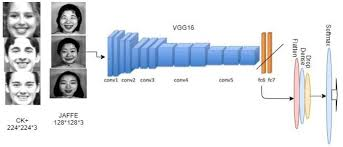](http://)


The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral). The training set consists of 28,709 examples and the public test set consists of 3,589 examples.








[Dataset link ](https://www.kaggle.com/msambare/fer2013)

Device: cuda
Train: 22968  Val: 5741  Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Poids classes: ['1.026', '9.191', '1.010', '0.568', '0.832', '0.847', '1.279']


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


  0%|          | 0.00/528M [00:00<?, ?B/s]

Paramètres entraînables : 133,639 / 14,848,327
  PHASE 1 — Warm-up  (backbone gelé, classifieur GAP)
  [P1] Ep  1/20  TrAcc=0.3381  VlAcc=0.3745  F1=0.3858  LR=5.00e-04  Gap=-0.036
  [P1] Ep  2/20  TrAcc=0.3839  VlAcc=0.3959  F1=0.4024  LR=5.00e-04  Gap=-0.012
  [P1] Ep  3/20  TrAcc=0.3934  VlAcc=0.4214  F1=0.4247  LR=5.00e-04  Gap=-0.028
  [P1] Ep  4/20  TrAcc=0.4045  VlAcc=0.4154  F1=0.4289  LR=5.00e-04  Gap=-0.011
  [P1] Ep  5/20  TrAcc=0.4057  VlAcc=0.4292  F1=0.4344  LR=5.00e-04  Gap=-0.024
  [P1] Ep  6/20  TrAcc=0.4069  VlAcc=0.4221  F1=0.4331  LR=5.00e-04  Gap=-0.015
  [P1] Ep  7/20  TrAcc=0.4105  VlAcc=0.4222  F1=0.4309  LR=5.00e-04  Gap=-0.012
  [P1] Ep  8/20  TrAcc=0.4161  VlAcc=0.4410  F1=0.4433  LR=5.00e-04  Gap=-0.025
  [P1] Ep  9/20  TrAcc=0.4146  VlAcc=0.4510  F1=0.4568  LR=5.00e-04  Gap=-0.036
  [P1] Ep 10/20  TrAcc=0.4194  VlAcc=0.4264  F1=0.4367  LR=5.00e-04  Gap=-0.007
  [P1] Ep 11/20  TrAcc=0.4206  VlAcc=0.4463  F1=0.4523  LR=5.00e-04  Gap=-0.026
  [P1] Ep 12/20  Tr

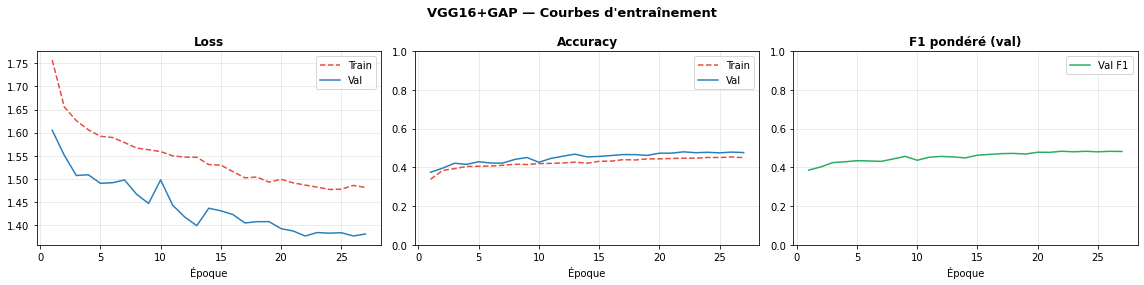

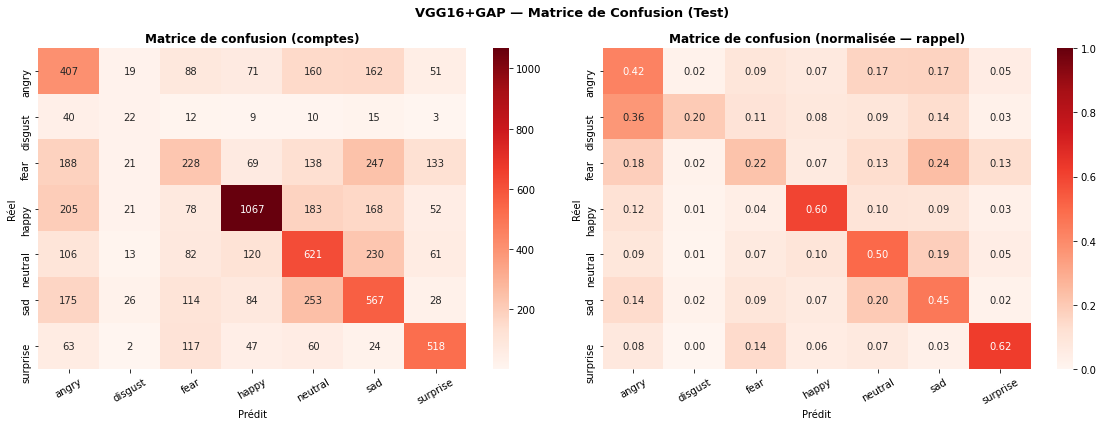

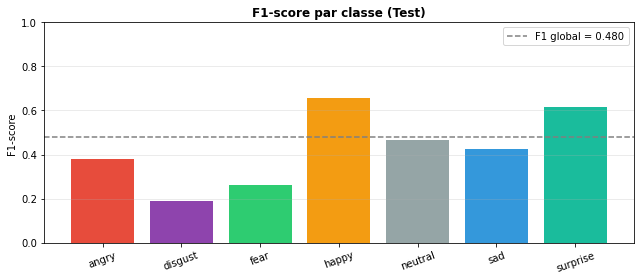

✅ Figures et rapport sauvegardés dans results/
  Modèle sauvegardé
  Dossier    : /kaggle/working/saved_model/
  Accuracy   : 47.78%
  F1 pondéré : 0.4795

  ── Rechargement ───────────────────────────────────────
  model = models.vgg16(weights=None)
  model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
  model.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 256), nn.BatchNorm1d(256),
      nn.ReLU(), nn.Dropout(0.5),
      nn.Linear(256, 7),
  )
  ckpt = torch.load("vgg16_gap_fer2013_checkpoint_XXXX.pth")
  model.load_state_dict(ckpt["model_state_dict"])
  model.eval()
  ───────────────────────────────────────────────────────

✅ ZIPs prêts : results.zip  saved_model.zip


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════════════════

import os, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
RESULTS_DIR = "results"
CKPT_DIR    = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,    exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
import random
from PIL import ImageEnhance

class RandomSharpness:
    def __init__(self, factor=2, p=0.3):
        self.factor = factor
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            enhancer = ImageEnhance.Sharpness(img)
            img = enhancer.enhance(self.factor)
        return img
EMOTION_LABELS = ["angry","disgust","fear","happy","neutral","sad","surprise"]


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 2 — DATASET PATH
# ═══════════════════════════════════════════════════════════════════════════

DATASET_PATH = "/kaggle/input/datasets/takouaayadi/preprocessed-dataset/preprocessed_dataset"


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 3 — TRANSFORMS
#
# FIX : Grayscale AVANT les augmentations géométriques (pas après),
#       et un seul transform universel pour le train — plus simple et stable.
# ═══════════════════════════════════════════════════════════════════════════

# Statistiques ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # L → RGB (3 canaux)
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    RandomSharpness(factor=2, p=0.3),   # 👈 ICI
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    # FIX — RandomErasing APRÈS ToTensor (travaille sur tensor, pas PIL)
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 4 — DATALOADERS ET POIDS DE CLASSES
# ═══════════════════════════════════════════════════════════════════════════

BATCH_SIZE   = 32
NUM_WORKERS  = 2

train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train", transform=train_transform
)
val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/val", transform=val_transform
)
test_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test", transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

# FIX — Poids normalisés (formule correcte avec n_classes au dénominateur)
counts  = Counter([lbl for _, lbl in train_dataset.samples])
total   = sum(counts.values())
weights = torch.tensor(
    [total / (num_classes * counts[i]) for i in range(num_classes)],
    dtype=torch.float32
).to(device)
print("Poids classes:", [f"{w:.3f}" for w in weights.cpu().tolist()])


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 5 — ARCHITECTURE VGG16 AMÉLIORÉE
#
# FIX principal : ajout d'un AdaptiveAvgPool2d (GAP) entre le backbone et
# le classifieur. Cela réduit les features de 25 088 à 512 AVANT les
# couches FC, ce qui divise par ~50 le risque de surapprentissage dans
# le classifieur tout en préservant les features spatiales de VGG16.
# ═══════════════════════════════════════════════════════════════════════════

def build_vgg16(dropout_rate=0.5, freeze_backbone=True):
    model = models.vgg16(pretrained=True)

    # Geler tout le backbone pour la Phase 1
    for param in model.features.parameters():
        param.requires_grad = not freeze_backbone

    # FIX — GAP : réduit (7×7×512) → (1×1×512) = 512 features au lieu de 25 088
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # Classifieur compact — 512 entrées au lieu de 25 088
    model.classifier = nn.Sequential(
        nn.Flatten(),                      # (B, 512, 1, 1) → (B, 512)
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout_rate),
        nn.Linear(256, num_classes),       # 7 classes
    )

    return model.to(device)


model = build_vgg16(dropout_rate=0.5, freeze_backbone=True)

# Compter les params entraînables
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total_p:,}")


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 6 — FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION
# ═══════════════════════════════════════════════════════════════════════════

# FIX — Label Smoothing : réduit la confiance excessive du modèle sur les
# exemples d'entraînement, régularisation douce très efficace contre l'overfitting
criterion = nn.CrossEntropyLoss(weight=weights)


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        # FIX — Gradient clipping : évite les explosions de gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        n          += imgs.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels  = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        n          += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    return total_loss / n, correct / n, f1


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 7 — PHASE 1 : WARM-UP (backbone gelé)
#
# FIX — ReduceLROnPlateau sur val_loss + early stopping (patience=5)
# ═══════════════════════════════════════════════════════════════════════════

EPOCHS_PHASE1 = 20       # On peut se permettre plus d'époques avec early stopping
PATIENCE_P1   = 5

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

# FIX — weight_decay dans Adam (L2 régularisation)
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4, weight_decay=1e-4
)
# FIX — Scheduler sur val_loss (réduit LR si la val ne s'améliore plus)
scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode="min", patience=3, factor=0.5, min_lr=1e-6
)

best_val_f1   = 0.0
best_weights  = None
no_improve    = 0

print("=" * 60)
print("  PHASE 1 — Warm-up  (backbone gelé, classifieur GAP)")
print("=" * 60)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, optimizer_p1)
    vl_loss, vl_acc, vl_f1  = eval_epoch(model, val_loader)

    scheduler_p1.step(vl_loss)   # FIX — scheduler sur val_loss
    lr_now = optimizer_p1.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"  [P1] Ep {epoch:>2}/{EPOCHS_PHASE1}  "
          f"TrAcc={tr_acc:.4f}  VlAcc={vl_acc:.4f}  "
          f"F1={vl_f1:.4f}  LR={lr_now:.2e}  "
          f"Gap={tr_acc - vl_acc:.3f}")   # Affiche le gap train-val

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_weights = copy.deepcopy(model.state_dict())
        no_improve   = 0
        torch.save(best_weights, f"{CKPT_DIR}/vgg16_best_phase1.pth")
    else:
        no_improve += 1
        if no_improve >= PATIENCE_P1:
            print(f"  ⚠ Early stopping Phase 1 à l'époque {epoch}")
            break

model.load_state_dict(best_weights)
print(f"\n  ✔ Meilleur F1 val Phase 1 : {best_val_f1:.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 8 — PHASE 2 : FINE-TUNING (dégel progressif)
#
# FIX — Seules features[24:] dégelées (conv4_3 + conv5_x)
# FIX — Optimiser uniquement filter(requires_grad) et non model.parameters()
# FIX — CosineAnnealingLR à la place du StepLR brutal
# ═══════════════════════════════════════════════════════════════════════════

# Dégel des 3 derniers blocs convolutifs uniquement
for param in model.features[24:].parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Paramètres entraînables Phase 2 : {trainable_p2:,}")

EPOCHS_PHASE2 = 15
PATIENCE_P2   = 5

# FIX — SGD Nesterov uniquement sur les params entraînables
#        LR 10× plus petit qu'en Phase 1
optimizer_p2 = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5, momentum=0.9, weight_decay=1e-4, nesterov=True
)
# FIX — CosineAnnealing : décroissance douce jusqu'à eta_min
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=EPOCHS_PHASE2, eta_min=1e-7
)

best_val_f1_p2 = 0.0
no_improve_p2  = 0

print("=" * 60)
print("  PHASE 2 — Fine-tuning  (features[24:] dégelées)")
print("=" * 60)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, optimizer_p2)
    vl_loss, vl_acc, vl_f1  = eval_epoch(model, val_loader)

    scheduler_p2.step()   # CosineAnnealing : step() sans argument
    lr_now = optimizer_p2.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"  [P2] Ep {epoch:>2}/{EPOCHS_PHASE2}  "
          f"TrAcc={tr_acc:.4f}  VlAcc={vl_acc:.4f}  "
          f"F1={vl_f1:.4f}  LR={lr_now:.2e}  "
          f"Gap={tr_acc - vl_acc:.3f}")

    if vl_f1 > best_val_f1_p2:
        best_val_f1_p2 = vl_f1
        best_weights   = copy.deepcopy(model.state_dict())
        no_improve_p2  = 0
        torch.save(best_weights, f"{CKPT_DIR}/vgg16_best_phase2.pth")
    else:
        no_improve_p2 += 1
        if no_improve_p2 >= PATIENCE_P2:
            print(f"  ⚠ Early stopping Phase 2 à l'époque {epoch}")
            break

model.load_state_dict(best_weights)
print(f"\n  ✔ Meilleur F1 val Phase 2 : {best_val_f1_p2:.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 9 — ÉVALUATION SUR LE JEU DE TEST
# ═══════════════════════════════════════════════════════════════════════════

test_loss, test_acc, test_f1 = eval_epoch(model, test_loader)

# Prédictions complètes pour les visualisations
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        y_pred.extend(outputs.argmax(1).cpu().tolist())
        y_true.extend(labels.tolist())

print("\n" + "=" * 60)
print("  RÉSULTATS FINAUX — Test Set")
print("=" * 60)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test F1 (wtd) : {test_f1:.4f}")
print(f"  Test Loss     : {test_loss:.4f}")
print("\n" + classification_report(y_true, y_pred,
      target_names=train_dataset.classes, digits=4, zero_division=0))


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE 10 — VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════════════

n_p1 = sum(1 for _ in range(len(history["train_loss"])))  # total époques
epochs_all = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_all, history["train_loss"], "--", label="Train", color="#e74c3c")
axes[0].plot(epochs_all, history["val_loss"],   "-",  label="Val",   color="#2980b9")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Époque")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_all, history["train_acc"], "--", label="Train", color="#e74c3c")
axes[1].plot(epochs_all, history["val_acc"],   "-",  label="Val",   color="#2980b9")
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Époque")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_all, history["val_f1"], "-", color="#27ae60", label="Val F1")
axes[2].set_title("F1 pondéré (val)", fontweight="bold")
axes[2].set_xlabel("Époque")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("VGG16+GAP — Courbes d'entraînement", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title("Matrice de confusion (comptes)", fontweight="bold")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")
axes[0].tick_params(axis="x", rotation=30)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1,
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title("Matrice de confusion (normalisée — rappel)", fontweight="bold")
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Réel")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("VGG16+GAP — Matrice de Confusion (Test)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# F1 par classe
report = classification_report(y_true, y_pred,
                                target_names=train_dataset.classes,
                                output_dict=True, zero_division=0)
f1_scores = pd.Series({cls: report[cls]["f1-score"] for cls in train_dataset.classes})
plt.figure(figsize=(9, 4))
bars = plt.bar(f1_scores.index, f1_scores.values,
               color=["#e74c3c","#8e44ad","#2ecc71","#f39c12","#95a5a6","#3498db","#1abc9c"])
plt.axhline(y=test_f1, linestyle="--", color="gray", label=f"F1 global = {test_f1:.3f}")
plt.title("F1-score par classe (Test)", fontweight="bold")
plt.ylabel("F1-score"); plt.ylim(0, 1)
plt.xticks(rotation=20); plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/f1_scores.png", dpi=150)
plt.show()

pd.DataFrame(report).T.to_csv(f"{RESULTS_DIR}/classification_report.csv")
print("✅ Figures et rapport sauvegardés dans results/")


# ═══════════════════════════════════════════════════════════════════════════
# CELLULE FINALE — SAUVEGARDE DU MODÈLE
# ═══════════════════════════════════════════════════════════════════════════

import json
from datetime import datetime

SAVE_DIR  = "/kaggle/working/saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# Poids seuls
torch.save(model.state_dict(), f"{SAVE_DIR}/vgg16_gap_fer2013_weights_{ts}.pth")

# Checkpoint complet
torch.save({
    "model_state_dict":   model.state_dict(),
    "test_accuracy":      test_acc,
    "test_f1":            test_f1,
    "history":            history,
    "class_names":        train_dataset.classes,
    "timestamp":          ts,
    "architecture":       "VGG16 + GAP + compact classifier",
    "hyperparams": {
        "lr_phase1":    5e-4,
        "lr_phase2":    5e-5,
        "dropout":      0.5,
        "batch_size":   BATCH_SIZE,
        "label_smooth": 0.1,
    },
}, f"{SAVE_DIR}/vgg16_gap_fer2013_checkpoint_{ts}.pth")

# Métadonnées JSON
with open(f"{SAVE_DIR}/meta_{ts}.json", "w") as f:
    json.dump({
        "model": "VGG16+GAP", "dataset": "FER2013",
        "test_accuracy": round(test_acc, 4),
        "test_f1":       round(test_f1,  4),
        "class_names":   train_dataset.classes,
        "saved_at":      ts,
    }, f, indent=2)

print("=" * 55)
print("  Modèle sauvegardé")
print("=" * 55)
print(f"  Dossier    : {SAVE_DIR}/")
print(f"  Accuracy   : {test_acc*100:.2f}%")
print(f"  F1 pondéré : {test_f1:.4f}")
print("""
  ── Rechargement ───────────────────────────────────────
  model = models.vgg16(weights=None)
  model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
  model.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 256), nn.BatchNorm1d(256),
      nn.ReLU(), nn.Dropout(0.5),
      nn.Linear(256, 7),
  )
  ckpt = torch.load("vgg16_gap_fer2013_checkpoint_XXXX.pth")
  model.load_state_dict(ckpt["model_state_dict"])
  model.eval()
  ───────────────────────────────────────────────────────
""")

import shutil
shutil.make_archive("/kaggle/working/results", "zip", RESULTS_DIR)
shutil.make_archive("/kaggle/working/saved_model", "zip", SAVE_DIR)
print("✅ ZIPs prêts : results.zip  saved_model.zip")